In [2]:
!python --version

Python 3.11.9


In [5]:
## Importing dataset

from sklearn.datasets import fetch_california_housing

#load dataset

df = fetch_california_housing(as_frame=True)

X = df.data
Y = df.target

In [7]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [8]:
Y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [10]:
# perform basic shapes thing 
#Split before any further analysis to avoid leaking global params to model

from sklearn.model_selection import train_test_split

#Split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [12]:
# Exploring X_train

X_train.shape

(16512, 8)

In [13]:
X_train.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,3.880754,28.608285,5.435235,1.096685,1426.453004,3.096961,35.643149,-119.582290
std,1.904294,12.602499,2.387375,0.433215,1137.056380,11.578744,2.136665,2.005654
min,0.499900,1.000000,0.888889,0.333333,3.000000,0.692308,32.550000,-124.350000
25%,2.566700,18.000000,4.452055,1.006508,789.000000,2.428799,33.930000,-121.810000
50%,3.545800,29.000000,5.235874,1.049286,1167.000000,2.817240,34.260000,-118.510000
75%,4.773175,37.000000,6.061037,1.100348,1726.000000,3.280000,37.720000,-118.010000
max,15.000100,52.000000,141.909091,25.636364,35682.000000,1243.333333,41.950000,-114.310000


In [14]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 16512 entries, 14196 to 15795
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      16512 non-null  float64
 1   HouseAge    16512 non-null  float64
 2   AveRooms    16512 non-null  float64
 3   AveBedrms   16512 non-null  float64
 4   Population  16512 non-null  float64
 5   AveOccup    16512 non-null  float64
 6   Latitude    16512 non-null  float64
 7   Longitude   16512 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB


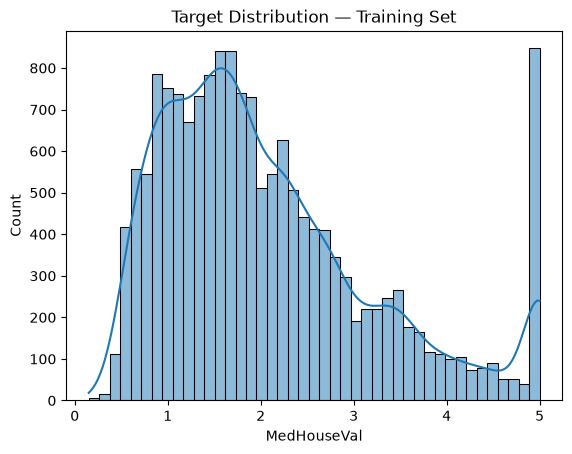

In [15]:
# Checking distribution 
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(y_train, kde=True)
plt.title("Target Distribution — Training Set")
plt.show()

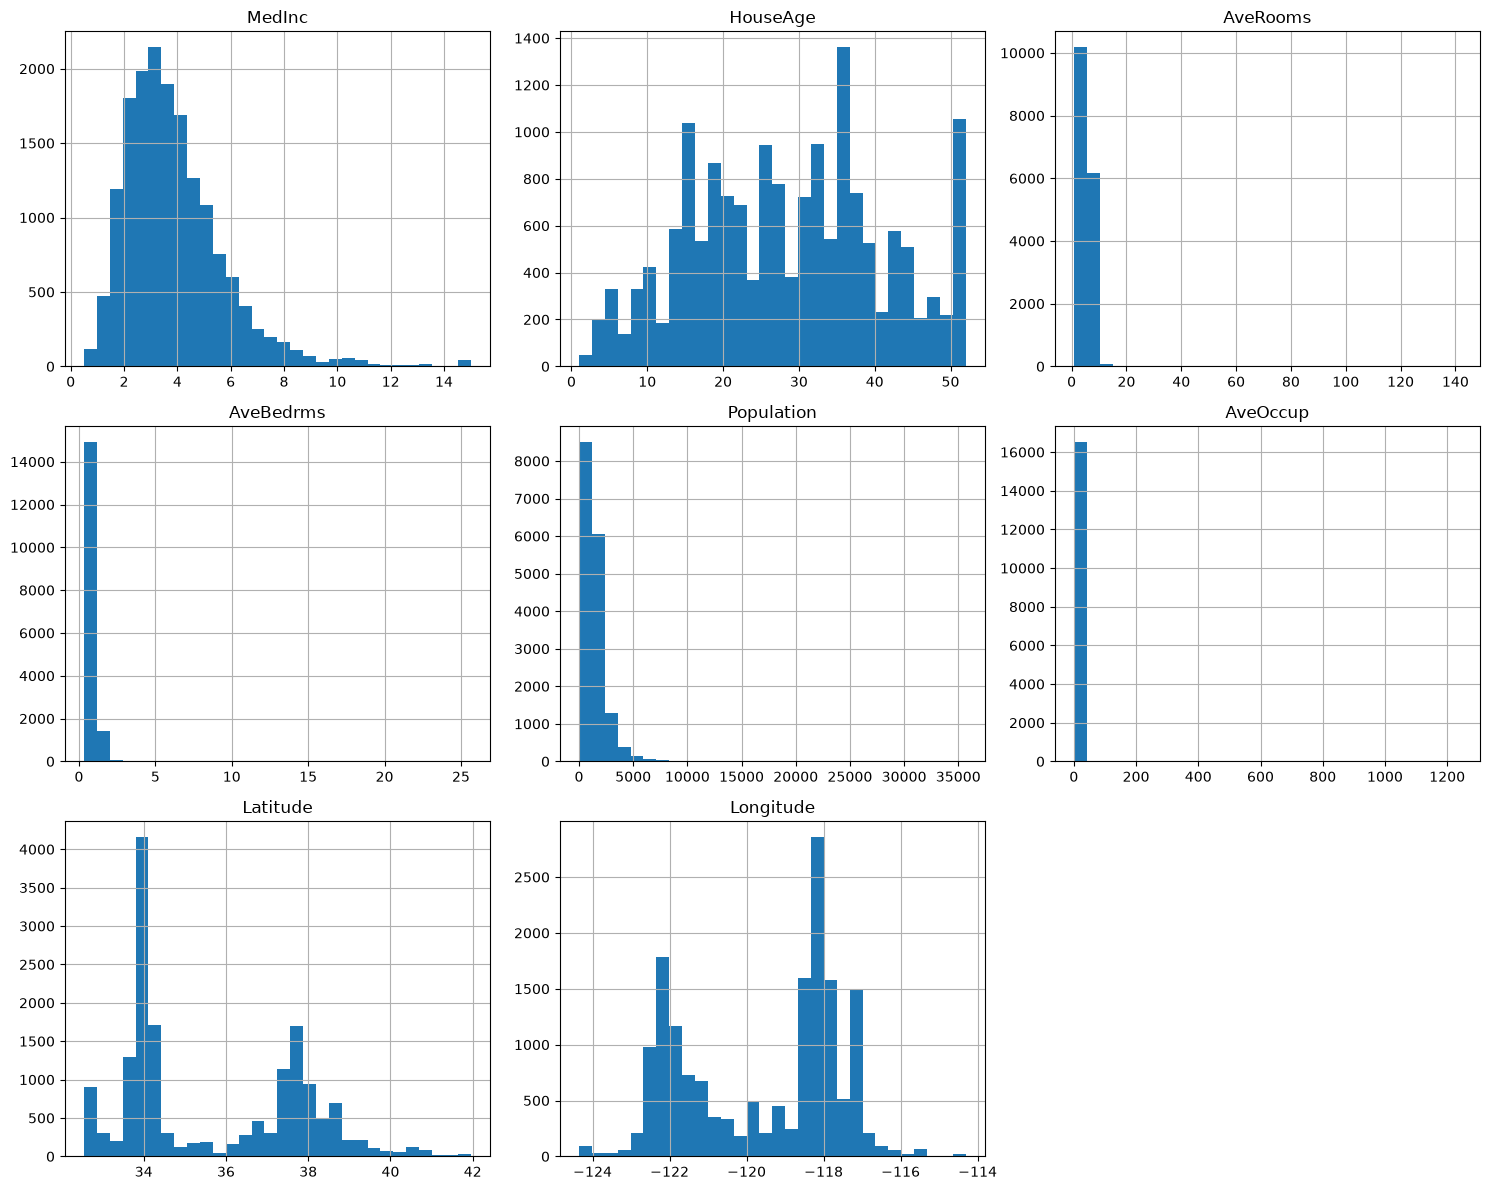

In [16]:
X_train.hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

In [17]:
#Checking nulls
X_train.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [18]:
#Upon reading docs, there is no nulls in it 

In [21]:
#Skewness
numeric_features = X_train.select_dtypes("float64").columns

In [22]:
skewness = X_train[numeric_features].skew()

skewness = skewness.sort_values(ascending=False)

skewness

AveOccup      88.052663
AveBedrms     23.170746
AveRooms      18.607090
Population     5.276131
MedInc         1.634090
Latitude       0.461504
HouseAge       0.063453
Longitude     -0.288418
dtype: float64

AveOccup, AveBedrms, AveRooms, Population is highly skewed


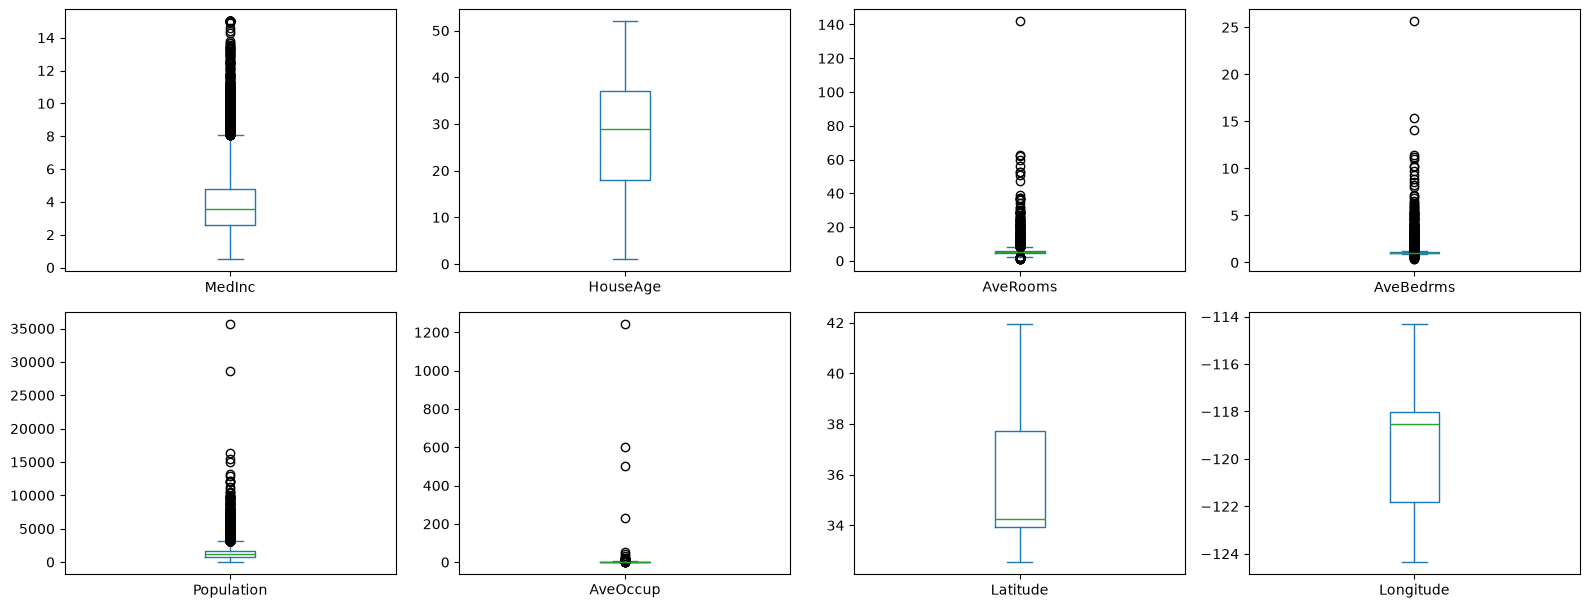

In [26]:
#Identifying outliers

X_train[numeric_features].plot(
    kind="box",
    subplots=True,
    layout=(4, 4),
    figsize=(16, 12),
    sharex=False,
    sharey=False
)

plt.tight_layout()
plt.show()


Median Inc, AveRooms, AveBedrms, Pop, AveOccup have outliers
Will see what to do with them later


In [30]:
#Outlier counts

Q1 = X_train[numeric_features].quantile(0.25)
Q3 = X_train[numeric_features].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = ((X_train[numeric_features] < lower_bound) | (X_train[numeric_features] > upper_bound)).sum()
outlier_counts = outlier_counts.sort_values(ascending=False)

In [32]:
outlier_counts[outlier_counts>0]

AveBedrms     1153
Population     955
AveOccup       582
MedInc         529
AveRooms       410
dtype: int64

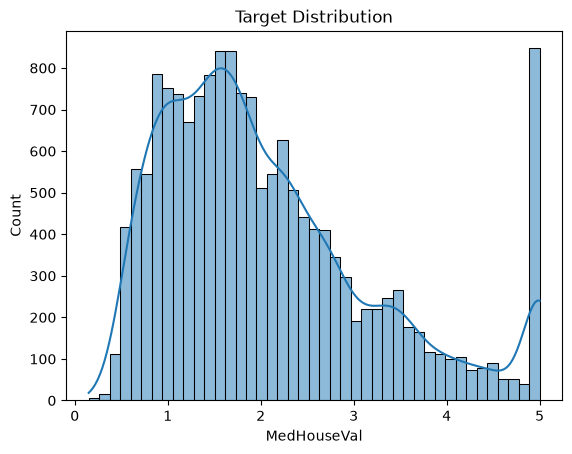

In [33]:
#Checking target distribution
sns.histplot(y_train, kde=True)
plt.title("Target Distribution")
plt.show()

In [34]:
#Skew
y_train.skew()

np.float64(0.9765310043609889)

moderate skewness

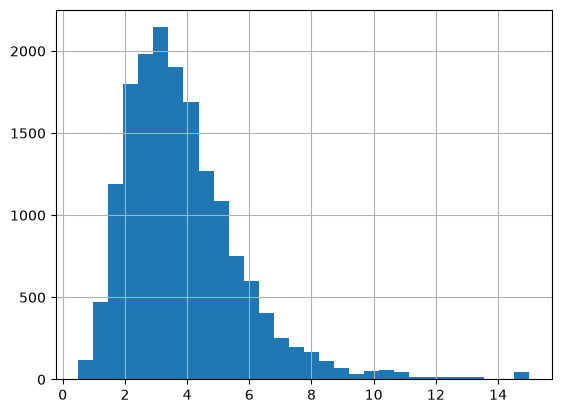

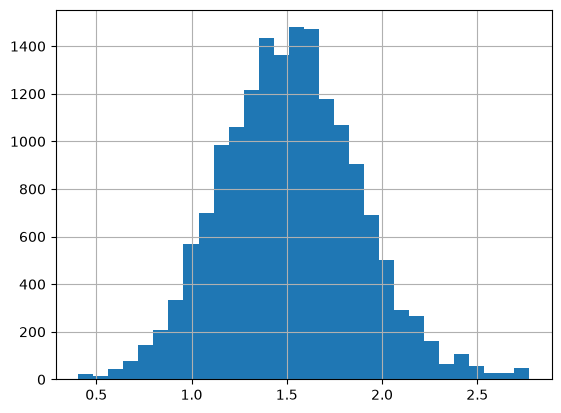

In [37]:
#Let's check transformation helps or not 
import numpy as np

X_train["MedInc"].hist(bins=30)
plt.show()

np.log1p(X_train["MedInc"]).hist(bins=30)
plt.show()

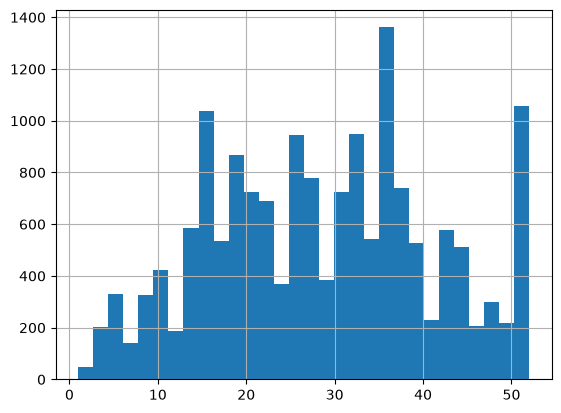

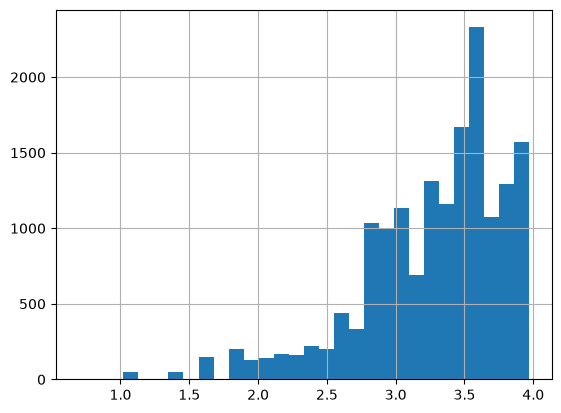

In [41]:
X_train["HouseAge"].hist(bins=30)
plt.show()

np.log1p(X_train["HouseAge"]).hist(bins=30)
plt.show()

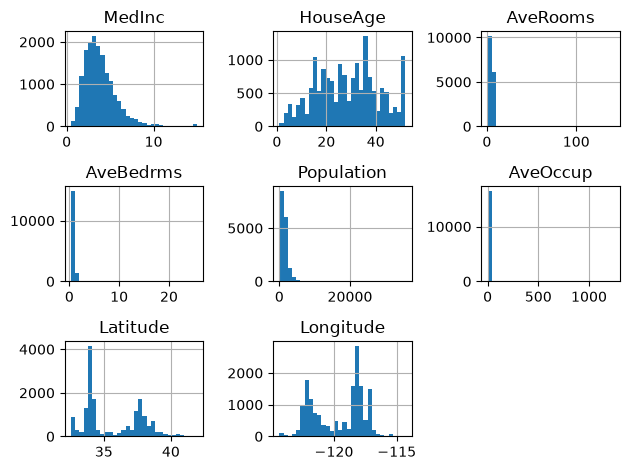

E:\30days\end-to-end_ml_regression\practice\myenv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


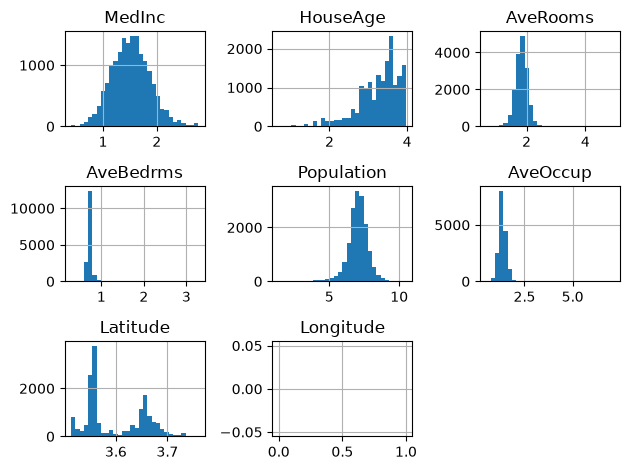

In [43]:
X_train[numeric_features].hist(bins=30)
plt.tight_layout()
plt.show()

np.log1p(X_train[numeric_features]).hist(bins=30)
plt.tight_layout()
plt.show()

MedInc, AveRooms, AveBedrooms, Population, AveOccup gets the help from transformation